In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [14]:
EMBEDDINGS_PATH = "results/toy_network/r0.25/mltn2v_results.csv"
NET_NAME = "toy_network"
NUM_SEGMENTS = 1
RANDOM_STATE = 43

In [15]:
embeddings = pd.read_csv(EMBEDDINGS_PATH, header=None)
embeddings.head()

,0,1,2
0,0,1.671785,0.652265
1,1,1.877267,0.816021
2,2,1.767633,0.720457
3,3,1.917794,0.860047
4,4,1.787712,0.702175


In [16]:
vectors = embeddings.to_numpy()[:, 1:]
labels = embeddings.to_numpy()[:, 0]

## Vis

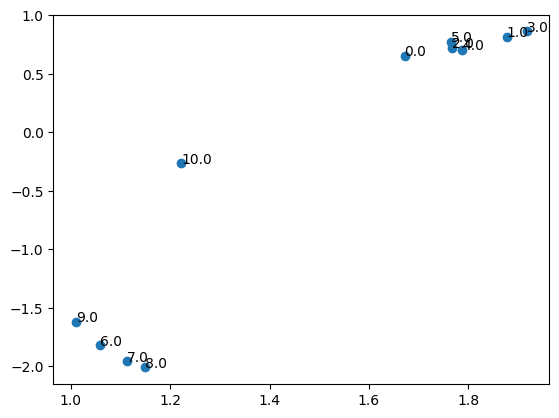

In [17]:
fig, ax = plt.subplots(nrows=1, ncols=1)
ax.scatter(x=vectors[:, 0], y=vectors[:, 1])
for x, y, s in zip(vectors[:, 0], vectors[:, 1], labels):
    ax.text(x=x, y=y, s=s)

## Find seeds with K-Means

In [18]:
kmeans = KMeans(n_clusters=NUM_SEGMENTS, random_state=RANDOM_STATE)
kmeans.fit(X=vectors)

KMeans(n_clusters=1, random_state=43)

In [19]:
seeds_ids = []
seeds_coords = []

for segment in range(NUM_SEGMENTS):

    segment_vectors = vectors[kmeans.labels_ == segment]
    segment_labels = labels[kmeans.labels_ == segment]
    segment_centre = kmeans.cluster_centers_[segment, :][np.newaxis, :]

    seg_seed_id_, _ = pairwise_distances_argmin_min(segment_centre, segment_vectors)

    seg_seed_id = segment_labels[seg_seed_id_]
    seg_seed_coords = segment_vectors[seg_seed_id_]

    seeds_ids.append(seg_seed_id)
    seeds_coords.append(seg_seed_coords)

seeds_ids = np.array(seeds_ids)
seeds_coords = np.array(seeds_coords).squeeze(axis=1)

seeds_ids

array([[10.]])

## Visualisation

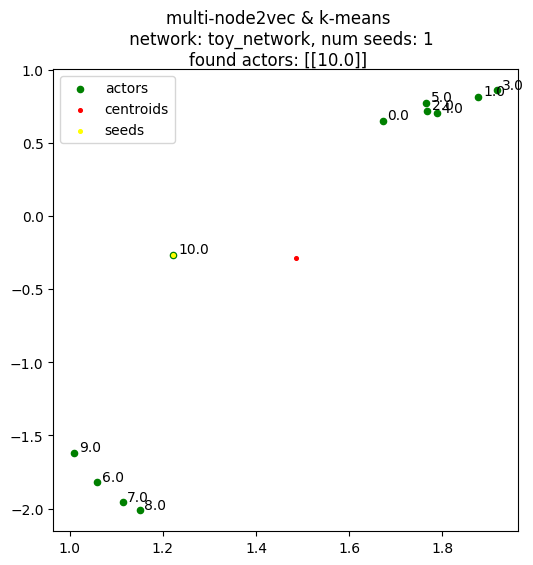

In [20]:
fig, ax = plt.subplots(nrows=1, ncols=1)
fig.set_size_inches(6, 6)
fig.suptitle(
    f"multi-node2vec & k-means\n network: {NET_NAME}, num seeds: {NUM_SEGMENTS}\n"
    f"found actors: {seeds_ids.tolist()}"
)

# plot embedded actors
ax.scatter(x=vectors[:, 0], y=vectors[:, 1], color="green", s=20, label="actors")
for x, y, s in zip(vectors[:, 0]+0.01, vectors[:, 1]+0.01, labels):
    ax.text(x=x, y=y, s=s)

# plot centroids
ax.scatter(x=kmeans.cluster_centers_[:, 0],y=kmeans.cluster_centers_[:, 1], color="red", s=7, label="centroids")

# mark seeds
ax.scatter(x=seeds_coords[:, 0],y=seeds_coords[:, 1], color="yellow", s=7, label="seeds")

ax.legend()